# Aula 2 — Dimensões de Qualidade de Dados

**Disciplina:** Validação de Dados e Bibliotecas de Qualidade  
**Curso:** Pós-Graduação em Machine Learning — FIAP POSTECH

---

Nesta aula prática, utilizaremos Python e a biblioteca `ydata-profiling` para realizar uma **auditoria de qualidade de dados** em um **dataset sintético**. 

A vantagem de construirmos nossos próprios dados é que podemos **injetar problemas de qualidade intencionalmente** para demonstrar como detectá-los nas seguintes dimensões:
- **Completude:** Dados faltantes (*missing data*)
- **Acurácia:** Valores irreais ou absurdos
- **Consistência:** Contradições lógicas entre diferentes colunas
- **Unicidade:** Registros duplicados

1. **Passo 1** — Geração do dataset sintético com anomalias
2. **Passo 2** — Geração de relatório automático com `ydata-profiling`
3. **Passo 3** — Análise e visualização de completude
4. **Passo 4** — Verificação de consistência, acurácia e unicidade com regras de negócio


## Ambiente e Bibliotecas

In [ ]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

# Seed para reproducibilidade
np.random.seed(42)

# Configurações visuais
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## Passo 1: Geração do Dataset Sintético

Vamos simular uma base de dados de **Clientes de E-commerce**. Geraremos dados válidos e, em seguida, corromperemos algumas linhas de forma proposital para criar problemas didáticos em cada dimensão de qualidade de dados.

In [2]:
# 1. Gerar dados válidos (baseline)
n_samples = 1000

df = pd.DataFrame({
    'id_cliente': range(1, n_samples + 1),
    'idade': np.random.normal(35, 12, n_samples).astype(int),
    'renda_mensal': np.random.lognormal(mean=8, sigma=1, size=n_samples),
    'uf': np.random.choice(['SP', 'RJ', 'MG', 'RS'], size=n_samples),
    'score_credito': np.random.randint(300, 850, n_samples)
})

# Garantir que a baseline faça sentido
df['idade'] = df['idade'].clip(18, 90)
df['cidade'] = df['uf'].map({
    'SP': 'São Paulo',
    'RJ': 'Rio de Janeiro',
    'MG': 'Belo Horizonte',
    'RS': 'Porto Alegre'
})

# 2. Injetar problemas de COMPLETUDE (Valores Nulos)
idx_missing_idade = np.random.choice(df.index, size=80, replace=False)
df.loc[idx_missing_idade, 'idade'] = np.nan

idx_missing_uf = np.random.choice(df.index, size=45, replace=False)
df.loc[idx_missing_uf, 'uf'] = np.nan

# 3. Injetar problemas de ACURÁCIA (Valores Absurdos/Inválidos)
idx_acuracia_idade = np.random.choice(df.dropna().index, size=15, replace=False)
df.loc[idx_acuracia_idade[:5], 'idade'] = -10
df.loc[idx_acuracia_idade[5:15], 'idade'] = 150

idx_acuracia_renda = np.random.choice(df.index, size=10, replace=False)
df.loc[idx_acuracia_renda, 'renda_mensal'] = -5000.0

# 4. Injetar problemas de CONSISTÊNCIA (Contradições lógicas)
# Exemplo: UF é 'SP' mas a cidade é 'Rio de Janeiro'
idx_consistencia = np.random.choice(df[df['uf'] == 'SP'].index, size=20, replace=False)
df.loc[idx_consistencia, 'cidade'] = 'Rio de Janeiro'

# 5. Injetar problemas de UNICIDADE (Registros Duplicados)
# Duplicamos 30 linhas aleatórias
duplicados = df.sample(30, random_state=42)
df = pd.concat([df, duplicados], ignore_index=True)

# Embaralha o dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.to_csv('clientes_ecommerce_sintetico.csv', index=False)

print(f'Dataset gerado com sucesso! Shape: {df.shape}')
print('\nVisão geral dos dados:')
display(df.head())

Dataset gerado com sucesso! Shape: (1030, 6)

Visão geral dos dados:


,id_cliente,idade,renda_mensal,uf,score_credito,cidade
0,32,NaN,-5000.000000,RJ,807,Rio de Janeiro
1,110,34.0,20211.991662,SP,594,São Paulo
2,137,25.0,9793.463858,NaN,684,São Paulo
3,89,28.0,2300.675039,RJ,360,Rio de Janeiro
4,919,NaN,2519.601874,RJ,803,Rio de Janeiro


---
## Passo 2: Profiling com ydata-profiling

Com o dataset gerado, vamos submetê-lo à biblioteca `ydata-profiling`. O relatório detectará automaticamente várias anomalias, especialmente em **completude** (valores nulos) e **unicidade** (duplicadas).

In [3]:
# Gera o relatório de qualidade
profile = ProfileReport(
    df.drop(columns=['id_cliente']),
    title='Clientes E-commerce – Relatório de Qualidade',
    explorative=True,
    correlations={"auto": {"calculate": False}} # Desabilitado para focar em estatísticas simples
)

# Salva o relatório como arquivo HTML interativo
profile.to_file('relatorio_qualidade_sintetico.html')
print('Relatório salvo em relatorio_qualidade_sintetico.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 103819.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Relatório salvo em relatorio_qualidade_sintetico.html


In [4]:
# Extrai métricas automaticamente do profile
desc = profile.get_description()

print(f'Linhas duplicadas identificadas : {desc.table["n_duplicates"]}')

print('\nAlertas detectados:')
for alerta in desc.alerts:
    print(f'  [{alerta.alert_type.name}] {alerta.column_name}')

Linhas duplicadas identificadas : 30

Alertas detectados:
  [DUPLICATES] None
  [MISSING] idade
  [MISSING] uf


---
## Passo 3: Completude e Missing Data

A **completude** responde à pergunta: *Temos todos os dados necessários para o nosso modelo?*
Vamos inspecionar programaticamente as colunas afetadas.

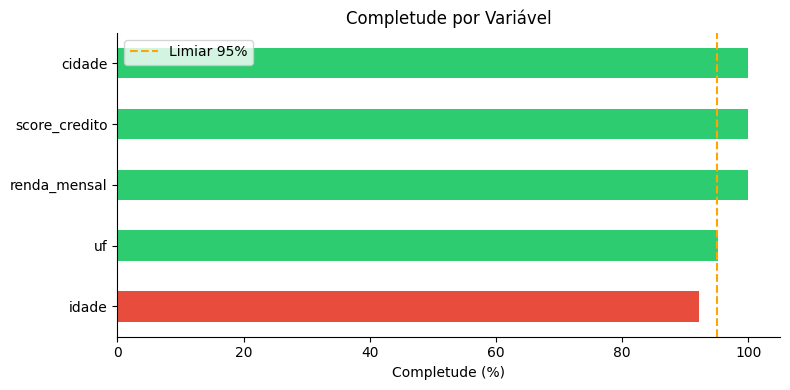

Colunas com completude < 95%:
  idade: 92.1% completo (81 valores ausentes)


In [5]:
# Completude por variável (em percentual)
completude = (1 - df.drop(columns=['id_cliente'], errors='ignore').isnull().mean()) * 100

cores = ['#e74c3c' if v < 95 else '#2ecc71' for v in completude.sort_values()]

fig, ax = plt.subplots(figsize=(8, 4))
completude.sort_values().plot(kind='barh', color=cores, ax=ax)
ax.axvline(95, color='orange', linestyle='--', linewidth=1.5, label='Limiar 95%')
ax.set_xlabel('Completude (%)')
ax.set_title('Completude por Variável')
ax.legend()

plt.tight_layout()
plt.savefig('completude.png')
plt.show()

# Resumo quantitativo
print('Colunas com completude < 95%:')
problematicas = completude[completude < 95].sort_values()
for col, val in problematicas.items():
    n_ausentes = df[col].isnull().sum()
    print(f'  {col}: {val:.1f}% completo ({n_ausentes} valores ausentes)')

---
## Passo 4: Acurácia, Consistência e Unicidade

Agora validaremos as **regras de negócio** para encontrar os problemas de **acurácia** (valores impossíveis no mundo real) e **consistência** (incoerências lógicas entre campos). A **unicidade** será avaliada checando a Primary Key (ID do Cliente).

=== Verificação de Regras de Qualidade ===
✗ Acurácia: Idade Inválida (<0 ou >120): 15 registros (1.46%)
✗ Acurácia: Renda Negativa: 10 registros (0.97%)
✗ Consistência: Cidade incompatível c/ UF: 20 registros (1.94%)
✗ Unicidade: Cliente Duplicado: 60 registros (5.83%)


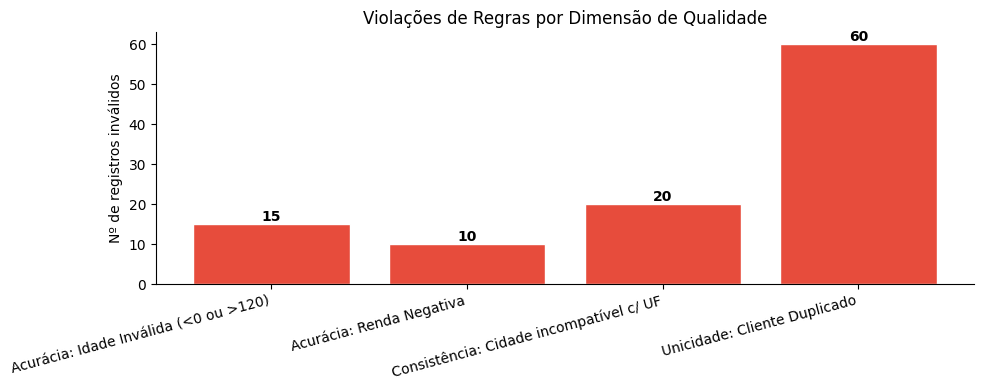

In [6]:
# Definição das Regras de Negócio
regras_qualidade = {
    'Acurácia: Idade Inválida (<0 ou >120)': (~df['idade'].between(0, 120)) & df['idade'].notnull(),
    'Acurácia: Renda Negativa': (df['renda_mensal'] < 0) & df['renda_mensal'].notnull(),
    'Consistência: Cidade incompatível c/ UF': (
        (df['uf'] == 'SP') & (df['cidade'] != 'São Paulo') |
        (df['uf'] == 'RJ') & (df['cidade'] != 'Rio de Janeiro') |
        (df['uf'] == 'MG') & (df['cidade'] != 'Belo Horizonte') |
        (df['uf'] == 'RS') & (df['cidade'] != 'Porto Alegre')
    ) & df['uf'].notnull() & df['cidade'].notnull(),
    'Unicidade: Cliente Duplicado': df.drop(columns=['id_cliente'], errors='ignore').duplicated(keep=False)
}

print('=== Verificação de Regras de Qualidade ===')
resultados = []
for regra, mask in regras_qualidade.items():
    n = mask.sum()
    status = '✓' if n == 0 else '✗'
    print(f'{status} {regra}: {n} registros ({n / len(df):.2%})')
    resultados.append({'regra': regra, 'n_violacoes': n})

# Resumo visual
df_res = pd.DataFrame(resultados)
fig, ax = plt.subplots(figsize=(10, 4))
cores_barras = ['#e74c3c' if n > 0 else '#2ecc71' for n in df_res['n_violacoes']]
bars = ax.bar(df_res['regra'], df_res['n_violacoes'], color=cores_barras, edgecolor='white')
ax.set_title('Violações de Regras por Dimensão de Qualidade')
ax.set_ylabel('Nº de registros inválidos')
ax.set_xlabel('')
plt.xticks(rotation=15, ha='right')
for bar, n in zip(bars, df_res['n_violacoes']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(n), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('violacoes_acuracia.png')
plt.show()


In [7]:
print('\n=== Exemplos de Violações Encontradas ===')
for regra, mask in regras_qualidade.items():
    if mask.sum() > 0:
        print(f'\n--- Exemplos para: {regra} ---')
        display(df[mask].head())


=== Exemplos de Violações Encontradas ===

--- Exemplos para: Acurácia: Idade Inválida (<0 ou >120) ---


,id_cliente,idade,renda_mensal,uf,score_credito,cidade
55,71,-10.0,2844.320338,RJ,342,Rio de Janeiro
57,801,150.0,19954.115380,RS,407,Porto Alegre
100,569,150.0,624.814086,RJ,746,Rio de Janeiro
451,339,-10.0,2021.961141,MG,670,Belo Horizonte
537,325,-10.0,3179.484688,SP,353,São Paulo



--- Exemplos para: Acurácia: Renda Negativa ---


,id_cliente,idade,renda_mensal,uf,score_credito,cidade
0,32,NaN,-5000.0,RJ,807,Rio de Janeiro
9,536,35.0,-5000.0,SP,491,São Paulo
15,585,NaN,-5000.0,RS,487,Porto Alegre
176,704,18.0,-5000.0,MG,543,Belo Horizonte
223,781,37.0,-5000.0,MG,491,Belo Horizonte



--- Exemplos para: Consistência: Cidade incompatível c/ UF ---


,id_cliente,idade,renda_mensal,uf,score_credito,cidade
23,650,NaN,39718.154011,SP,442,Rio de Janeiro
48,825,29.0,3528.593653,SP,462,Rio de Janeiro
183,763,65.0,3214.521008,SP,677,Rio de Janeiro
239,290,NaN,346.232116,SP,361,Rio de Janeiro
253,441,39.0,5784.176443,SP,492,Rio de Janeiro



--- Exemplos para: Unicidade: Cliente Duplicado ---


,id_cliente,idade,renda_mensal,uf,score_credito,cidade
2,137,25.0,9793.463858,NaN,684,São Paulo
5,236,42.0,15353.777369,SP,402,São Paulo
12,77,36.0,628.551585,RS,338,Porto Alegre
66,679,46.0,8089.408546,MG,723,Belo Horizonte
69,281,36.0,3406.841534,SP,505,São Paulo


---
## Síntese

Construir e corromper um dataset sintético nos permitiu visualizar na prática as falhas mais comuns em um pipeline de dados:

| Dimensão | O que testamos | Exemplo injetado |
|---|---|---|
| **Completude** | Dados Faltantes | Células nulas inseridas em `idade` e `uf` |
| **Acurácia** | Plausibilidade dos dados | `idade` configurada para 150 anos e `renda_mensal` negativa |
| **Consistência** | Coerência lógica entre atributos | Cliente alocado em `uf` SP, mas `cidade` no Rio de Janeiro |
| **Unicidade** | Existência de duplicações absolutas | 30 linhas foram totalmente copiadas e coladas no dataset |

Na prática profissional, etapas como esta justificam a necessidade de se criar regras rígidas de **Data Cleaning** antes que os dados cheguem a um algoritmo de Machine Learning.

---
## Referências

- Fan, J. (2025). *An Interdisciplinary and Cross-Task Review on Missing Data Imputation*. arXiv:2511.01196.
- Wang, R. Y. & Strong, D. M. (1996). *Beyond Accuracy: What Data Quality Means to Data Consumers*. Journal of Management Information Systems, 12(4), 5-33.
- ISO/IEC 5259-4:2024. *Artificial intelligence — Data quality for analytics and machine learning (ML) — Part 4: Data quality process framework*.
- Rubin, D. B. (1976). *Inference and Missing Data*. Biometrika, 63(3), 581-592.
- YDATA AI (2024). *ydata-profiling: Data Quality Profiling for Pandas and Spark DataFrames*. Disponível em: https://docs.profiling.ydata.ai/
